In [ ]:
!pip install catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.9 MB/s eta 0:00:00


In [ ]:
!pip install association_metrics --quiet

  Preparing metadata (setup.py) ... done


In [ ]:
!pip install kagglehub[pandas-datasets] --quiet
!pip install pandas matplotlib seaborn --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import association_metrics as am
from scipy.stats import skew
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, roc_auc_score, classification_report, auc)
from sklearn import set_config
import kagglehub
warnings.filterwarnings('ignore')

In [ ]:
print("🔽 Downloading from Kaggle...")
dataset_path = kagglehub.dataset_download("uciml/adult-census-income")
path = os.path.join(dataset_path, "adult.csv")
data = pd.read_csv(path)

🔽 Downloading from Kaggle...


100%|██████████| 450k/450k [00:00<00:00, 15.0MB/s]

Extracting files...


In [ ]:
df = data.copy()

In [ ]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


**STEP 1 : DATA UNDERSTANDING**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


**Prolem 1 : Missing value**

In [ ]:
print(round((df.isnull().sum() / df.shape[0]) * 100, 2).astype(str) + ' %')

age               0.0 %
workclass         0.0 %
fnlwgt            0.0 %
education         0.0 %
education.num     0.0 %
marital.status    0.0 %
occupation        0.0 %
relationship      0.0 %
race              0.0 %
sex               0.0 %
capital.gain      0.0 %
capital.loss      0.0 %
hours.per.week    0.0 %
native.country    0.0 %
income            0.0 %
dtype: object


In [ ]:
# Check for '?' in dataset
print(round((df.isin(['?']).sum() / df.shape[0])
      * 100, 2).astype(str) + ' %')

age                0.0 %
workclass         5.64 %
fnlwgt             0.0 %
education          0.0 %
education.num      0.0 %
marital.status     0.0 %
occupation        5.66 %
relationship       0.0 %
race               0.0 %
sex                0.0 %
capital.gain       0.0 %
capital.loss       0.0 %
hours.per.week     0.0 %
native.country    1.79 %
income             0.0 %
dtype: object


In [ ]:
#  Replace '?' values
df = df.replace('?', np.nan)
print(round((df.isnull().sum() / df.shape[0]) * 100, 2).astype(str) + ' %')

age                0.0 %
workclass         5.64 %
fnlwgt             0.0 %
education          0.0 %
education.num      0.0 %
marital.status     0.0 %
occupation        5.66 %
relationship       0.0 %
race               0.0 %
sex                0.0 %
capital.gain       0.0 %
capital.loss       0.0 %
hours.per.week     0.0 %
native.country    1.79 %
income             0.0 %
dtype: object


In [ ]:
numeric_cols       = [col for col in df.iloc[:, :-1].columns if df[col].dtypes != 'O']
categorical_cols   = [col for col in df.iloc[:, :-1].columns if df[col].dtypes == 'O']
missingValue_cols  = [col for col in df.iloc[:, :-1].columns if df[col].isnull().sum() >0 ]
print('Numeric_cols:', numeric_cols)
print('Categorical_cols:', categorical_cols)
print('MissingValue_cols:', missingValue_cols)

Numeric_cols: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']
Categorical_cols: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
MissingValue_cols: ['workclass', 'occupation', 'native.country']


In [ ]:
def FindMissingPercentByCol(data, col, display = 1):
  numberMissing = data[col].isnull().sum()
  percentMissing = np.round(numberMissing/data.shape[0], 5)*100
  if(display):
    print(f"{col} has {numberMissing} missing values with {percentMissing} percents")
  result = {}
  result["Feature"] = col
  result["MissingNum"] = numberMissing
  result["% Missing"] = percentMissing
  return result

def FindMissingPecent(data, display = 1):
  miss_list = []
  for col in data.columns:
    result = FindMissingPercentByCol(data, col, display = display)
    if(result["MissingNum"] > 0):
      miss_list.append(result)
  miss_df = pd.DataFrame(miss_list)
  miss_df = miss_df.sort_values(by = "MissingNum", ascending = 0)
  miss_df = miss_df.reset_index(drop = True)
  return miss_df


missing_df = FindMissingPecent(df, display = 0)
display(missing_df)

,Feature,MissingNum,% Missing
0,occupation,1843,5.660
1,workclass,1836,5.639
2,native.country,583,1.790


**Prolem 2 : Outliers**

In [ ]:
def outlier_problem(df, numeric_cols):
    stats = []

    for col in numeric_cols:
        Q1 = np.quantile(df[col], 0.25)
        Q3 = np.quantile(df[col], 0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outlier_df = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_count = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

        stats.append([col, Q1, Q3, IQR, lower_bound, upper_bound, outlier_count])

    df_stats = pd.DataFrame(stats, columns=['Feature', 'Q1', 'Q3', 'IQR', 'Lower_Bound', 'Upper_Bound', 'Outlier_Count'])

    return df_stats,  outlier_df

df_stats,  outlier_df = outlier_problem(df, numeric_cols )
display(df_stats,  outlier_df)

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count
0,age,28.0,48.0,20.0,-2.0,78.0,143
1,fnlwgt,117827.0,237051.0,119224.0,-61009.0,415887.0,992
2,education.num,9.0,12.0,3.0,4.5,16.5,1198
3,capital.gain,0.0,0.0,0.0,0.0,0.0,2712
4,capital.loss,0.0,0.0,0.0,0.0,0.0,1519
5,hours.per.week,40.0,45.0,5.0,32.5,52.5,9008


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,NaN,>50K
12,52,Private,129177,Bachelors,13,Widowed,Other-service,Not-in-family,White,Female,0,2824,20,United-States,>50K
13,32,Private,136204,Masters,14,Separated,Exec-managerial,Not-in-family,White,Male,0,2824,55,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32544,72,NaN,129912,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,25,United-States,<=50K
32546,31,Private,199655,Masters,14,Divorced,Other-service,Not-in-family,Other,Female,0,0,30,United-States,<=50K
32547,39,Local-gov,111499,Assoc-acdm,12,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,0,20,United-States,>50K
32554,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K


**Prolem 3 : Skewness**

In [ ]:
skew_df = df[numeric_cols].skew().rename_axis('features').reset_index(name='skewness')
skew_df

,features,skewness
0,age,0.558743
1,fnlwgt,1.446980
2,education.num,-0.311676
3,capital.gain,11.953848
4,capital.loss,4.594629
5,hours.per.week,0.227643


**Prolem 4 : Imbalance**

In [ ]:
# Checking the counts of label categories
income = df['income'].value_counts(normalize=True)
class_df = round(income * 100, 2).astype('str') + ' %'
class_df = pd.DataFrame(class_df).rename(columns={'income': 'Class'}).reset_index()
class_df

,income,proportion
0,<=50K,75.92 %
1,>50K,24.08 %


**STEP 2 : EXPLORATORY DATA ANALYSIS**

**1. Univariate Analysis**

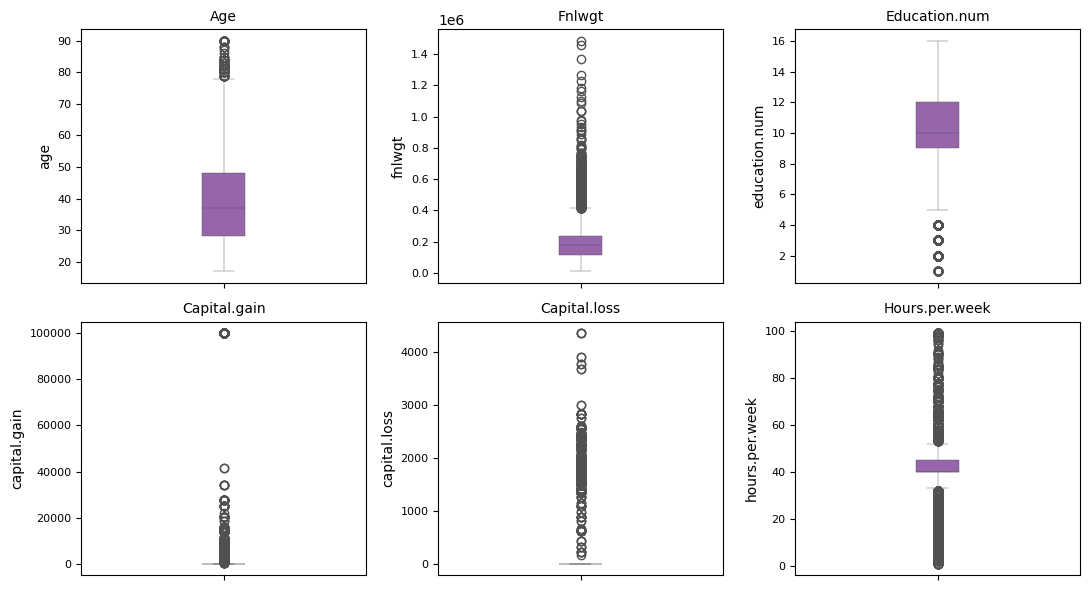

In [ ]:
my_colors = ["#9b59b6", "#3498db",
             "#2ecc71", "#006a4e"]
sns.set_palette(my_colors)

fig, axes = plt.subplots(2, 3, figsize=(11, 6))
flat_axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        y=df[col],
        orient="v",
        width=0.15,
        linewidth=0.3,
        ax=flat_axes[i]
    )

    flat_axes[i].set_title(col.capitalize(), fontsize=10)
    flat_axes[i].tick_params(labelsize=8)
    flat_axes[i].set_xlabel('')
    flat_axes[i].set_ylabel(col, fontsize=10)

    # 🔥 Tắt grid ở nền
    flat_axes[i].grid(False)

# Xóa subplot trống nếu có
for j in range(len(numeric_cols), len(flat_axes)):
    fig.delaxes(flat_axes[j])

plt.tight_layout()
plt.show()

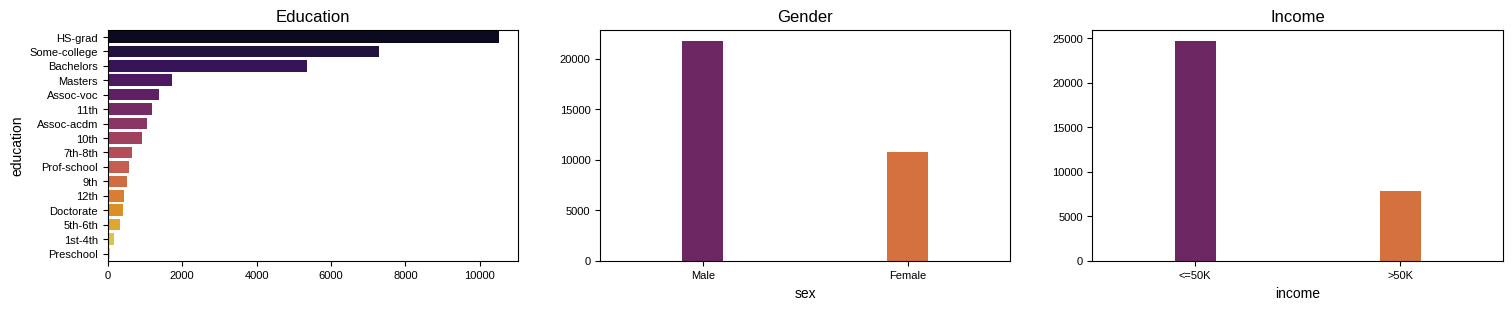

<Figure size 600x400 with 0 Axes>

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 3))

edu = df['education'].value_counts()
sns.barplot(x=edu.values, y=edu.index, ax=axes[0], palette='inferno', width=0.8)
axes[0].set_title('Education')
axes[0].tick_params(labelsize=8)
axes[0].grid(False)

gen = df['sex'].value_counts()
sns.barplot(x=gen.index, y=gen.values, ax=axes[1], palette='inferno', width=0.2)
axes[1].set_title('Gender')
axes[1].tick_params(labelsize=8)
axes[1].grid(False)

income = df['income'].value_counts()
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(6, 4))
sns.barplot(x = income.index, y = income.values, ax = axes[2]
            , palette='inferno', width=0.2)
axes[2].set_title('Income')
axes[2].tick_params(labelsize=8)
axes[2].grid(False)

plt.tight_layout()
plt.show()

**2. Bivariate Analysis**

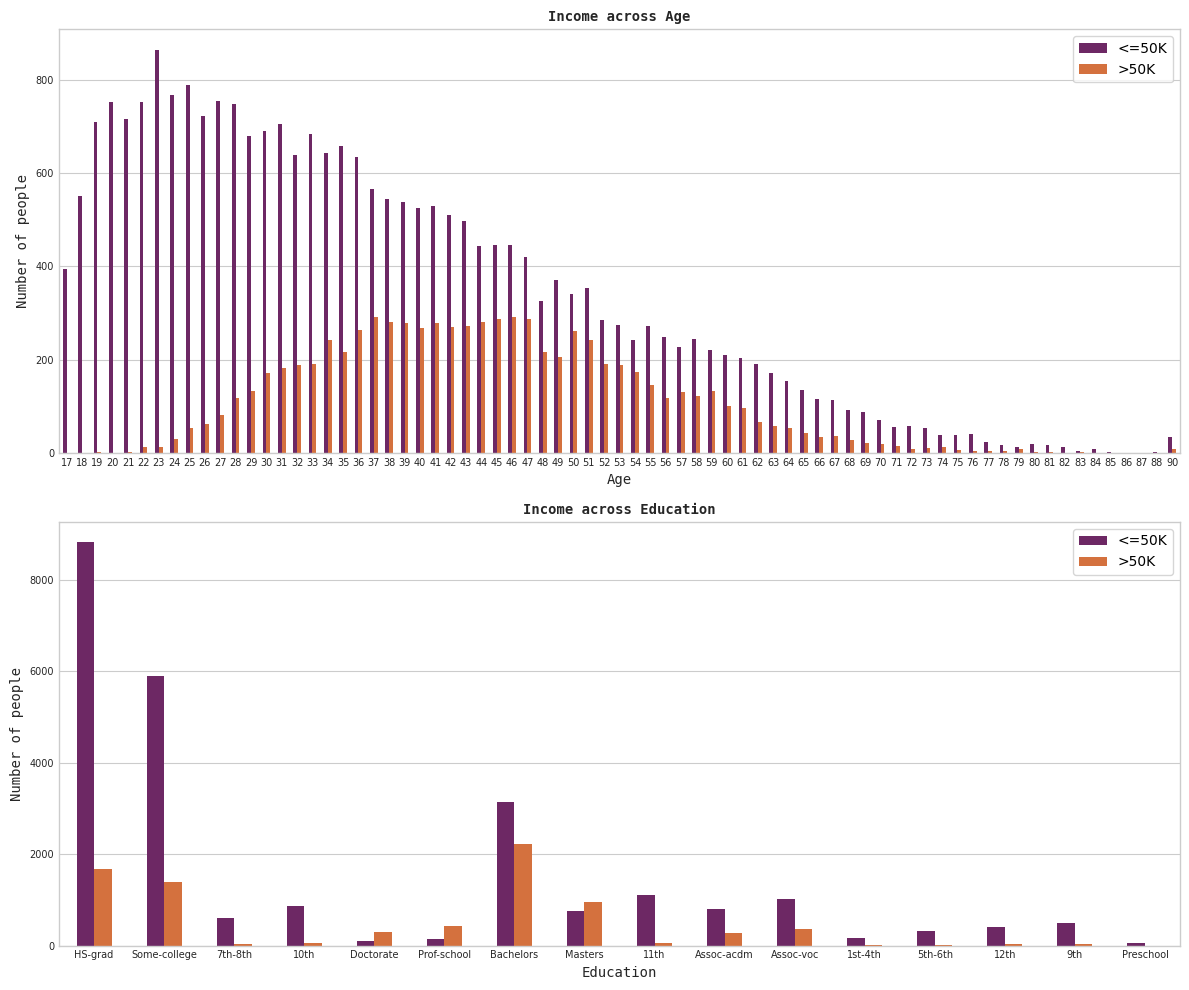

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Income across Age
plt.style.use('default')
sns.countplot(data=df, x='age', hue='income', ax = axes[0] , palette='inferno', width= 0.5)
axes[0].set_title('Income across Age', fontdict={
          'fontname': 'Monospace', 'fontsize': 10, 'fontweight': 'bold'})
axes[0].set_xlabel('Age', fontdict={'fontname': 'Monospace', 'fontsize': 10})
axes[0].set_ylabel('Number of people', fontdict={
           'fontname': 'Monospace', 'fontsize': 10})
axes[0].tick_params(labelsize=7)
axes[0].legend(loc=1, prop={'size': 10})


# Income across Education
plt.style.use('default')
sns.countplot(data=df, x='education',
              hue='income', ax = axes[1] , palette='inferno',width= 0.5)
axes[1].set_title('Income across Education', fontdict={
          'fontname': 'Monospace', 'fontsize': 10, 'fontweight': 'bold'})
axes[1].set_xlabel('Education', fontdict={'fontname': 'Monospace', 'fontsize': 10})
axes[1].set_ylabel('Number of people', fontdict={
           'fontname': 'Monospace', 'fontsize': 10})
axes[1].tick_params(labelsize=7)
axes[1].legend(loc=1, prop={'size': 10})


plt.tight_layout()
plt.show()

**3. Multivariate Analysis**

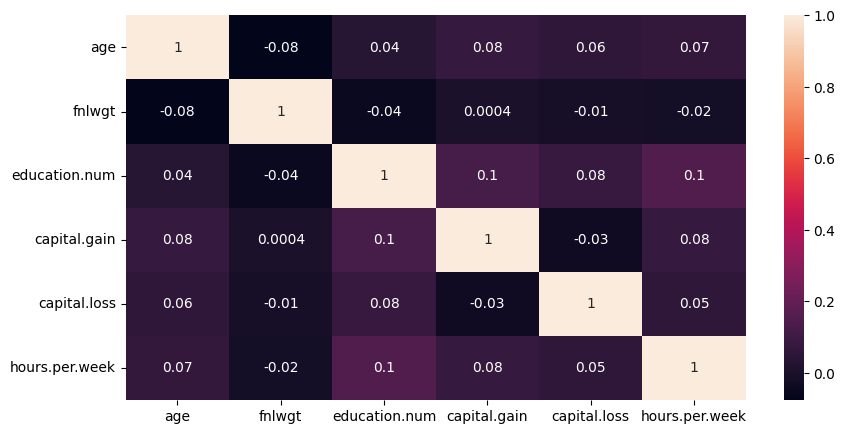

In [ ]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt = '.1g')
plt.show()

**STEP 3 : DATA REPROCESSING**

**1 . Train-Validation-Test Split**

In [ ]:
X = df.drop(columns=["income"])
y = df["income"]

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y,test_size=0.2
                                                            ,random_state=42,stratify=y )
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val,test_size=0.2
                                                  ,random_state=42,stratify=y_train_val)

print(X_train.shape, X_val.shape, y_train.shape, y_val.shape, X_test.shape, y_test.shape)
print(f'X_train', X_train.shape)
print(f'X_val', X_val.shape)
print(f'X_test', X_test.shape)

(20838, 14) (5210, 14) (20838,) (5210,) (6513, 14) (6513,)
X_train (20838, 14)
X_val (5210, 14)
X_test (6513, 14)


**2 . Missing-value Handling**





In [ ]:
def cat_corr_matrix(df,catFeatures):
  df_corr = df[catFeatures].copy()
  df_corr = df_corr.apply(lambda x: x.astype("category") if x.dtype == "O" else x)
  cramersv = am.CramersV(df_corr)
  categoric_corr_matrix = cramersv.fit()
  return categoric_corr_matrix

def get_top_k_corr(corr_matrix, target_col, k=3):
    corr_series = corr_matrix[target_col].drop(target_col)
    top_k = corr_series.sort_values(ascending=False).head(k)
    return top_k

def top_k_corr_df(matrix_corr_df, missing_cols):
  top_k_dict = {}
  for col in missing_cols:
    top_k_features = get_top_k_corr(matrix_corr_df, col, k=3)
    top_k_dict[col] = list(top_k_features.keys())
  return top_k_dict


categoric_corr_matrix = cat_corr_matrix(X_train, categorical_cols)
top_k_dict = top_k_corr_df(categoric_corr_matrix, missingValue_cols)
display(categoric_corr_matrix, top_k_dict )

,workclass,education,marital.status,occupation,relationship,race,sex,native.country
workclass,1.000000,0.103185,0.077585,0.215860,0.089541,0.056060,0.147907,0.051821
education,0.103185,1.000000,0.091033,0.200566,0.123647,0.079712,0.094428,0.138362
marital.status,0.077585,0.091033,1.000000,0.135028,0.489052,0.088855,0.461639,0.081164
occupation,0.215860,0.200566,0.135028,1.000000,0.182247,0.086192,0.440861,0.080411
relationship,0.089541,0.123647,0.489052,0.182247,1.000000,0.099100,0.647316,0.095680
race,0.056060,0.079712,0.088855,0.086192,0.099100,1.000000,0.116657,0.427943
sex,0.147907,0.094428,0.461639,0.440861,0.647316,0.116657,1.000000,0.063987
native.country,0.051821,0.138362,0.081164,0.080411,0.095680,0.427943,0.063987,1.000000


{'workclass': ['occupation', 'sex', 'education'],
 'occupation': ['sex', 'workclass', 'education'],
 'native.country': ['race', 'education', 'relationship']}

In [ ]:
top_k_dict_df = pd.DataFrame.from_dict(top_k_dict, orient='index', columns=['Top1', 'Top2', 'Top3'])
top_k_dict_df = top_k_dict_df.rename_axis('Feature').reset_index()
display(top_k_dict_df)

,Feature,Top1,Top2,Top3
0,workclass,occupation,sex,education
1,occupation,sex,workclass,education
2,native.country,race,education,relationship


In [ ]:
class CatBoostImputer(BaseEstimator, TransformerMixin):
    def __init__(self, impute_cols, topk_dict,
                 iterations=50, depth=4, learning_rate=0.1, verbose=False):
        self.impute_cols = impute_cols
        self.topk_dict = topk_dict
        self.iterations = iterations
        self.depth = depth
        self.learning_rate = learning_rate
        self.verbose = verbose
        self.models_dict_ = {}

    def fit(self, X, y=None):
        X = X.copy()
        for col in self.impute_cols:
            features = self.topk_dict[col]
            train_non_missing = X[X[col].notna()].copy()
            X_train = train_non_missing[features].astype(str).fillna("Unknown")
            y_train = train_non_missing[col]
            model = CatBoostClassifier(
                iterations=self.iterations,
                depth=self.depth,
                learning_rate=self.learning_rate,
                loss_function='MultiClass',
                verbose=False)

            model.fit(X_train, y_train, cat_features=features)
            self.models_dict_[col] = model
        return self
    def transform(self, X):
        X = X.copy()

        for col in self.impute_cols:
            features = self.topk_dict[col]
            model = self.models_dict_[col]
            missing_rows = X[X[col].isna()]
            if missing_rows.empty:
                continue
            X_pred = missing_rows[features].astype(str).fillna("Unknown")
            preds = model.predict(X_pred).flatten()
            X.loc[X[col].isna(), col] = preds
        return X


**3 . Outliers Handling**

**3.1 . Outliers Handling for Numeric Features**

In [ ]:
class OutlierHandler(BaseEstimator, TransformerMixin):
    def __init__(self, cols, method="iqr"):
        self.cols = cols
        self.method = method

    def fit(self, X, y=None):
        X = X.copy()
        if self.method == "iqr":
            self.bounds_ = {}
            for col in self.cols:
                Q1 = X[col].quantile(0.25)
                Q3 = X[col].quantile(0.75)
                IQR = Q3 - Q1
                self.bounds_[col] = (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols:
            lower, upper = self.bounds_[col]
            X[col] = X[col].clip(lower, upper)

        return X

**3.2 . Outliers Handling for Categorical Features**

In [ ]:
class RareCategoryHandler(BaseEstimator, TransformerMixin):
    def __init__(self, categorical_cols=None, threshold=0.01):
        self.categorical_cols = categorical_cols
        self.threshold = threshold
        self.rare_dict_ = {}

    def fit(self, X, y=None):
        X = X.copy()
        self.rare_dict_ = {}
        for col in self.categorical_cols:
            freq = X[col].value_counts(normalize=True)
            low_freq = freq[freq < self.threshold].index.tolist()
            self.rare_dict_[col] = low_freq
        return self

    def transform(self, X):
        X = X.copy()
        for col, rare_list in self.rare_dict_.items():
            X[col] = X[col].apply(lambda x: 'Other' if x in rare_list else x)

        return X

**STEP 4. FEATURE ENGINERING**

**1 . Ordinal Encoder & Label Encoder**

In [ ]:
class OrdinalEncoderCustom(BaseEstimator, TransformerMixin):
    def __init__(self, categorical_cols):
        self.categorical_cols = categorical_cols
        self.encoders = {}
    def fit(self, X, y=None):
        X = X.copy()
        for col in self.categorical_cols:
            enc = OrdinalEncoder(
                handle_unknown='use_encoded_value',
                unknown_value=-1)
            enc.fit(X[[col]])
            self.encoders[col] = enc
        return self
    def transform(self, X):
        X = X.copy()
        for col in self.categorical_cols:
            X[col] = self.encoders[col].transform(X[[col]])
        return X

In [ ]:
class LabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, unknown_value=-1):
        self.unknown_value = unknown_value
        self.classes_ = None
        self.mapping_ = None
        self.inverse_mapping_ = None

    def fit(self, y):
        y = pd.Series(y)
        self.classes_ = y.unique().tolist()
        self.mapping_ = {cls: idx for idx, cls in enumerate(self.classes_)}
        self.inverse_mapping_ = {idx: cls for cls, idx in self.mapping_.items()}
        return self
    def transform(self, y):
        y = pd.Series(y)
        return y.map(self.mapping_).fillna(self.unknown_value).astype(int).values


**2 . StandardScaler**

In [ ]:
class StandardScalerCustom(BaseEstimator, TransformerMixin):
    def __init__(self, numeric_cols):
        self.numeric_cols = numeric_cols
        self.scaler = StandardScaler()

    def fit(self, X, y=None):
        X = X.copy()
        self.scaler.fit(X[self.numeric_cols])
        return self
    def transform(self, X):
        X = X.copy()
        X[self.numeric_cols] = self.scaler.transform(X[self.numeric_cols])
        return X

**3 . PCA**

In [ ]:
class PCACustom(BaseEstimator, TransformerMixin):
    def __init__(self, numeric_cols, n_components=0.95):
        self.numeric_cols = numeric_cols
        self.n_components = n_components
        self.pca = PCA(n_components=n_components)
        self.feature_names_out_ = None
        self.explained_variance_ratio_ = None
        self.cumulative_variance_ratio_ = None
        self.variance_table_ = None
        self.n_components_kept_ = None

    def fit(self, X, y=None):
        X = X.copy()
        self.pca.fit(X[self.numeric_cols])
        self.n_components_kept_ = self.pca.n_components_

        self.feature_names_out_ = [f"PCA_{i+1}"
                                   for i in range(self.n_components_kept_)]

        self.explained_variance_ratio_ = self.pca.explained_variance_ratio_
        self.cumulative_variance_ratio_ = self.explained_variance_ratio_.cumsum()

        self.variance_table_ = pd.DataFrame({
            "PCA Component": self.feature_names_out_,
            "Explained Variance Ratio": self.explained_variance_ratio_,
            "Cumulative Variance Ratio": self.cumulative_variance_ratio_
        })
        return self

    def transform(self, X):
        X = X.copy()
        pca_values = self.pca.transform(X[self.numeric_cols])
        df_pca = pd.DataFrame(pca_values, columns=self.feature_names_out_, index=X.index)

        X_other = X.drop(columns=self.numeric_cols)

        return pd.concat([X_other, df_pca], axis=1)

**STEP 5. DATA PREPROCESSING PIPELINE**

**5.1 . Preprocessor Pipeline**

In [ ]:
preprocessor = Pipeline(steps=[
                                ("impute", CatBoostImputer(impute_cols= missingValue_cols, topk_dict= top_k_dict)),
                                ("outlier", OutlierHandler(numeric_cols)),
                                ("rare", RareCategoryHandler(categorical_cols=categorical_cols, threshold=0.01)),
                                ("encode", OrdinalEncoderCustom(categorical_cols)),
                                ("scale", StandardScalerCustom(numeric_cols)),
                                ("pca", PCACustom(numeric_cols=numeric_cols, n_components=0.95)),
                            ])

In [ ]:
set_config(display='diagram')
display(preprocessor)

Pipeline(steps=[('impute',
                 CatBoostImputer(impute_cols=['workclass', 'occupation',
                                              'native.country'],
                                 topk_dict={'native.country': ['race',
                                                               'education',
                                                               'relationship'],
                                            'occupation': ['sex', 'workclass',
                                                           'education'],
                                            'workclass': ['occupation', 'sex',
                                                          'education']})),
                ('outlier',
                 OutlierHandler(cols=['age', 'fnlwgt', 'education.num',
                                      'capital.gain', 'capital.loss',
                                      'h...
                 OrdinalEncoderCustom(categorical_cols=['workclass',
                                                        'education',
                                                        'marital.status',
                                                        'occupation',
                                                        'relationship', 'race',
                                                        'sex',
                                                        'native.country'])),
                ('scale',
                 StandardScalerCustom(numeric_cols=['age', 'fnlwgt',
                                                    'education.num',
                                                    'capital.gain',
                                                    'capital.loss',
                                                    'hours.per.week'])),
                ('pca',
                 PCACustom(numeric_cols=['age', 'fnlwgt', 'education.num',
                                         'capital.gain', 'capital.loss',
                                         'hours.per.week']))])

In [ ]:
X_train_pre = preprocessor.fit_transform(X_train)
X_val_pre   = preprocessor.transform(X_val)
X_test_pre  = preprocessor.transform(X_test)

**5.2 . Save embeddings**

In [ ]:
np.save("X_train_pre.npy", X_train_pre)
np.save("X_val_pre.npy",   X_val_pre)
np.save("X_test_pre.npy",  X_test_pre)

In [ ]:
from google.colab import files
files.download("X_train_pre.npy")
files.download("X_val_pre.npy")
files.download("X_test_pre.npy")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**5.3 . Outcome post data preprocessing**

In [ ]:
preprocessor.named_steps["impute"]
preprocessor.named_steps["outlier"]
preprocessor.named_steps["rare"]
preprocessor.named_steps["encode"]
preprocessor.named_steps["scale"]
preprocessor.named_steps["pca"]

PCACustom(numeric_cols=['age', 'fnlwgt', 'education.num', 'capital.gain',
                        'capital.loss', 'hours.per.week'])

In [ ]:
step1 = preprocessor.named_steps["impute"].transform(X_train.copy())
step2 = preprocessor.named_steps["outlier"].transform(step1.copy())
step3 = preprocessor.named_steps["rare"].transform(step2.copy())
step4 = preprocessor.named_steps["encode"].transform(step3.copy())
step5 = preprocessor.named_steps["scale"].transform(step4.copy())
step6 = preprocessor.named_steps["pca"].transform(step5.copy())

In [ ]:
pd.DataFrame(step5[numeric_cols]).describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,2.083800e+04,2.083800e+04,2.083800e+04,20838.0,20838.0,2.083800e+04
mean,2.659676e-16,-5.455746e-18,-1.104789e-16,0.0,0.0,4.248662e-16
std,1.000024e+00,1.000024e+00,1.000024e+00,0.0,0.0,1.000024e+00
min,-1.588103e+00,-1.834844e+00,-2.284633e+00,0.0,0.0,-1.410737e+00
25%,-7.765905e-01,-7.260932e-01,-4.571020e-01,0.0,0.0,-1.982421e-01
50%,-1.126257e-01,-8.661257e-02,-5.098401e-02,0.0,0.0,-1.982421e-01
75%,6.988868e-01,5.315471e-01,7.612521e-01,0.0,0.0,6.100877e-01
max,2.912103e+00,2.418008e+00,2.385724e+00,0.0,0.0,1.822582e+00


In [ ]:
pd.DataFrame(step5[numeric_cols]).skew().rename_axis('features').reset_index(name='skewness')

,features,skewness
0,age,0.526483
1,fnlwgt,0.543030
2,education.num,-0.041749
3,capital.gain,0.000000
4,capital.loss,0.000000
5,hours.per.week,0.433910


In [ ]:
def report_preprocessing(preprocessor, X_train):
    print("\n========================== BEFORE PROCESSING ==========================")
    print("Shape:", X_train.shape)
    print("\nNaN counts BEFORE:")
    print(X_train.isna().sum())

    print("\n========================== STEP 1: IMPUTATION ==========================")
    step1 = preprocessor.named_steps["impute"].transform(X_train.copy())
    print("Shape:", step1.shape)
    print("NaN counts AFTER imputation:")
    print(step1.isna().sum())

    print("\n========================== STEP 2: OUTLIER ============================")
    step2 = preprocessor.named_steps["outlier"].transform(step1.copy())
    print("Shape:", step2.shape)
    # In summary for numeric cols
    numeric_cols = preprocessor.named_steps["outlier"].cols
    print("\nSummary numeric columns after outlier handling:")
    print(step2[numeric_cols].describe())

    print("\n========================== STEP 3: RARE CATEGORY =====================")
    step3 = preprocessor.named_steps["rare"].transform(step2.copy())
    print("Shape:", step3.shape)

    cat_cols = preprocessor.named_steps["rare"].categorical_cols
    print("\nUnique counts (after rare handling):")
    for col in cat_cols:
        print(f"{col}: {step3[col].nunique()} unique values")

    print("\n========================== STEP 4: ENCODING ===========================")
    step4 = preprocessor.named_steps["encode"].transform(step3.copy())
    print("Shape:", step4.shape)

    print("\nSample encoded data:")
    print(step4.head())

    print("\n========================== STEP 5: SCALING ============================")
    step5 = preprocessor.named_steps["scale"].transform(step4.copy())
    step5_df = pd.DataFrame(step5, columns=step4.columns)

    print("Shape:", step5_df.shape)
    print("\nMean / Std AFTER scaling:")
    print(step5_df.describe().loc[["mean", "std"]])

    if "pca" in preprocessor.named_steps:
        print("\n========================== STEP 6: PCA ================================")
        step6 = preprocessor.named_steps["pca"].transform(step5)
        print("Shape:", step6.shape)
        pca = preprocessor.named_steps["pca"]
        print("\nExplained variance ratio per component:")
        print(pca.explained_variance_ratio_)
        print("\nVariance kept:")
        print(pca.n_components)
        print("\nNumber of PCA components kept:")
        print(pca.n_components_kept_)
        cum_var = pca.explained_variance_ratio_.cumsum()
        print("\nCumulative explained variance:")
        print(cum_var)
        pca_df = pd.DataFrame({
            "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
            "variance": pca.explained_variance_ratio_,
            "cumulative_variance": cum_var
        })
        print("\nPCA Variance Summary:")
        print(pca_df)
        return step1, step2, step3, step4, step5_df, step6

In [ ]:
step1, step2, step3, step4, step5, step6 = report_preprocessing(preprocessor, X_train)


========================== BEFORE PROCESSING ==========================
Shape: (20838, 14)

NaN counts BEFORE:
age                  0
workclass         1157
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1160
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     356
dtype: int64

========================== STEP 1: IMPUTATION ==========================
Shape: (20838, 14)
NaN counts AFTER imputation:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
dtype: int64

========================== STEP 2: OUTLIER ============================
Shape: (20838, 14)

Summary numeric columns after outlier handlin

**STEP 6. MODEL PIPELINE**

In [ ]:

logit = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=500))
])

svm = Pipeline([
    ("preprocessor", preprocessor),
    ("model", SVC())
])

rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier())
])

model = {
            "Logistic": logit,
            "SVM": svm,
            "RandomForest": rf,
        }


In [ ]:
enc         = LabelEncoder()
y_train_enc = enc.fit_transform(y_train)
y_val_enc   = enc.transform(y_val)
y_test_enc  = enc.transform(y_test)

display(y_train_enc, y_val_enc, y_test_enc)


array([0, 0, 1, ..., 1, 1, 1])

array([1, 1, 0, ..., 1, 0, 1])

array([1, 1, 0, ..., 0, 1, 1])

MODEL: Logistic
Accuracy: 0.8033

              precision    recall  f1-score   support

           0       0.64      0.41      0.50      1255
           1       0.83      0.93      0.88      3955

    accuracy                           0.80      5210
   macro avg       0.74      0.67      0.69      5210
weighted avg       0.79      0.80      0.79      5210




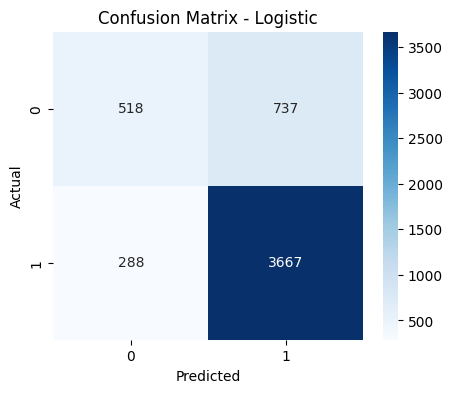

MODEL: SVM
Accuracy: 0.8140

              precision    recall  f1-score   support

           0       0.69      0.42      0.52      1255
           1       0.84      0.94      0.88      3955

    accuracy                           0.81      5210
   macro avg       0.76      0.68      0.70      5210
weighted avg       0.80      0.81      0.80      5210




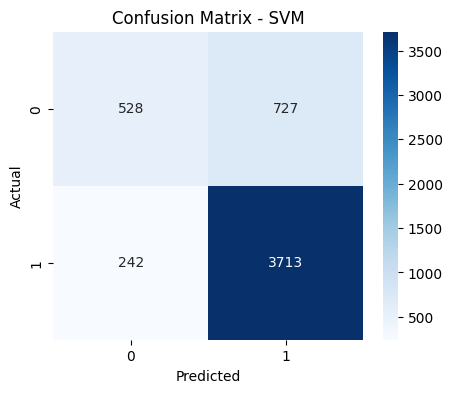

MODEL: RandomForest
Accuracy: 0.8221

              precision    recall  f1-score   support

           0       0.65      0.56      0.60      1255
           1       0.87      0.90      0.89      3955

    accuracy                           0.82      5210
   macro avg       0.76      0.73      0.74      5210
weighted avg       0.82      0.82      0.82      5210




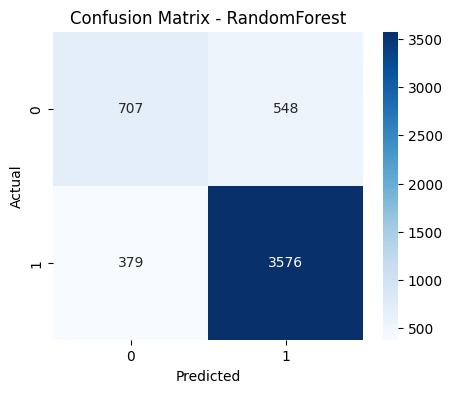

In [ ]:
for name, pipe in model.items():
    print("="*70)
    print(f"MODEL: {name}")
    print("="*70)

    pipe.fit(X_train, y_train_enc)
    y_pred = pipe.predict(X_val)
    acc = accuracy_score(y_val_enc, y_pred)
    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_val_enc, y_pred))
    print()
    cm = confusion_matrix(y_val_enc, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

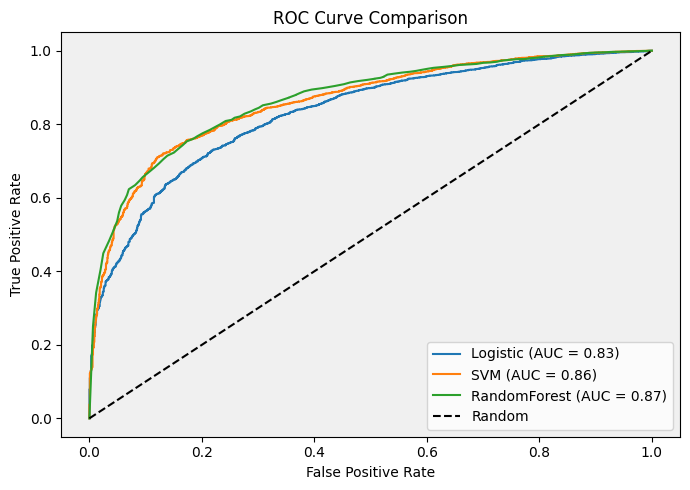

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.set_facecolor('#f0f0f0')
for name, pipe in model.items():
    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_val)[:, 1]
    else:
        y_score = pipe.decision_function(X_val)
    fpr, tpr, thresholds = roc_curve(y_val_enc, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--', label="Random")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.grid(False)
plt.show()

**STEP 7. MODEL TUNNING**

In [ ]:
param_grids = {
    "Logistic": {
        "model__C": [0.1, 1],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"]
    },

    "SVM": {
        "model__C": [1],
        "model__kernel": ["linear"],
        "model__gamma": ["scale"]
    },

    "RandomForest": {
        "model__n_estimators": [100],
        "model__max_depth": [5, None],
        "model__min_samples_split": [2]
    }
}

In [ ]:
def model_tunning(model, param_grids, X_train, y_train, X_val=None, y_val=None, cv=3):
    results = {}
    for name, pipeline in model.items():
        print(f"GridSearchCV for {name}")
        grid = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[name],
            scoring="accuracy",
            cv=cv,
            n_jobs=-1,
            verbose=1)
        grid.fit(X_train, y_train)
        results[name] = grid
        print("Best Score:", grid.best_score_)
        print("Best Params:", grid.best_params_)
        if X_val is not None and y_val is not None:
            y_val_pred = grid.predict(X_val)
            acc = accuracy_score(y_val, y_val_pred)
            precision = precision_score(y_val, y_val_pred, average='weighted')
            recall = recall_score(y_val, y_val_pred, average='weighted')
            f1 = f1_score(y_val, y_val_pred, average='weighted')
            report = classification_report(y_val, y_val_pred)
            cm = confusion_matrix(y_val, y_val_pred)
            print("Classification Report:\n", report)
            plt.figure(figsize=(5,4))
            sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
            plt.title(f"Confusion Matrix - {name}")
            plt.xlabel("Predicted")
            plt.ylabel("Actual")
            plt.show()
        print("-" * 60)
    return results

GridSearchCV for Logistic
Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best Score: 0.8068432671081678
Best Params: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.41      0.50      1255
           1       0.83      0.93      0.88      3955

    accuracy                           0.80      5210
   macro avg       0.74      0.67      0.69      5210
weighted avg       0.79      0.80      0.79      5210



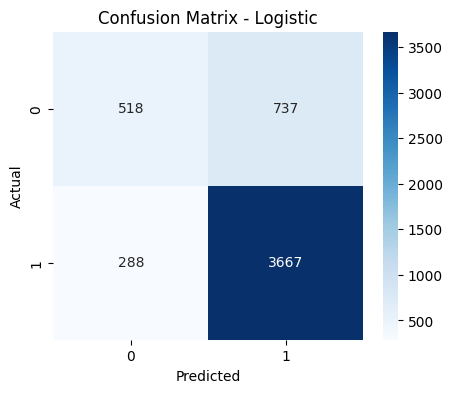

------------------------------------------------------------
GridSearchCV for SVM
Fitting 2 folds for each of 1 candidates, totalling 2 fits
Best Score: 0.8087148478740762
Best Params: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.40      0.49      1255
           1       0.83      0.93      0.88      3955

    accuracy                           0.80      5210
   macro avg       0.74      0.67      0.69      5210
weighted avg       0.79      0.80      0.79      5210



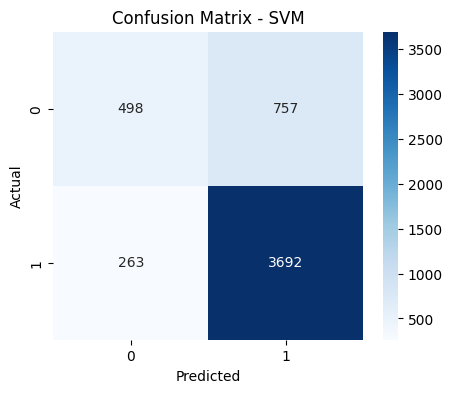

------------------------------------------------------------
GridSearchCV for RandomForest
Fitting 2 folds for each of 2 candidates, totalling 4 fits
Best Score: 0.82882234379499
Best Params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.56      0.60      1255
           1       0.87      0.90      0.89      3955

    accuracy                           0.82      5210
   macro avg       0.76      0.73      0.74      5210
weighted avg       0.81      0.82      0.82      5210



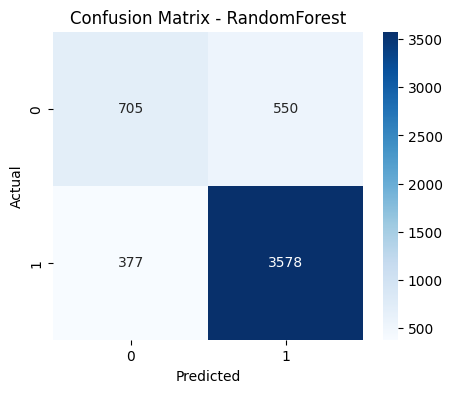

------------------------------------------------------------


In [ ]:
results = model_tunning(
                          model,
                          param_grids,
                          X_train,
                          y_train_enc,
                          X_val=X_val,
                          y_val=y_val_enc,
                          cv=2 )

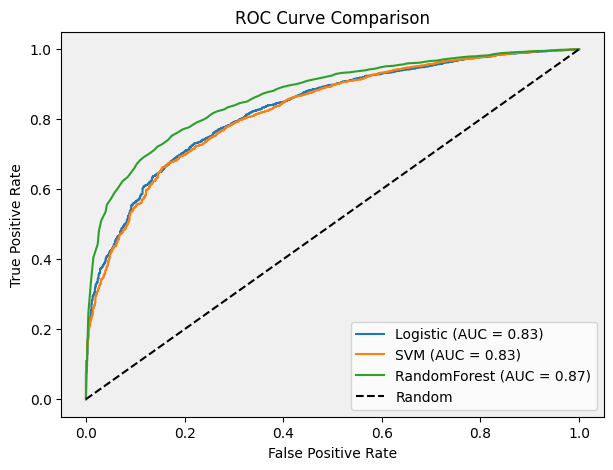

In [63]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
ax.set_facecolor('#f0f0f0')
for name, grid in results.items():
    best_model = grid.best_estimator_
    if hasattr(best_model, "predict_proba"):
        y_score = best_model.predict_proba(X_val)[:, 1]
    else:
        y_score = best_model.decision_function(X_val)
    fpr, tpr, _ = roc_curve(y_val_enc, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--', label="Random")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(False)
plt.show()

In [ ]:
best_model = None
best_score = -1
best_name = None
for name, grid in results.items():
    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_model = grid.best_estimator_
        best_name = name
print("Best Model:", best_name)
print("Score:", best_score)

In [ ]:
def evaluate_model(best_model, X_val, y_val, X_test, y_test):
    y_val_pred = best_model.predict(X_val)
    y_test_pred = best_model.predict(X_test)
    if hasattr(best_model, "predict_proba"):
        val_score = best_model.predict_proba(X_val)[:, 1]
        test_score = best_model.predict_proba(X_test)[:, 1]
    else:
        val_score = best_model.decision_function(X_val)
        test_score = best_model.decision_function(X_test)
    print("=== VALIDATION REPORT ===")
    print(classification_report(y_val, y_val_pred))
    print("ROC-AUC (val):", roc_auc_score(y_val, val_score))

    print("\n=== TEST REPORT ===")
    print(classification_report(y_test, y_test_pred))
    print("ROC-AUC (test):", roc_auc_score(y_test, test_score))
    def plot_cm(y_true, y_pred, title):
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(5,4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(title)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()
    plot_cm(y_val, y_val_pred, "Confusion Matrix - Validation")
    plot_cm(y_test, y_test_pred, "Confusion Matrix - Test")
    fpr_val, tpr_val, _ = roc_curve(y_val, val_score)
    fpr_test, tpr_test, _ = roc_curve(y_test, test_score)

    plt.figure(figsize=(8,5))
    ax = plt.gca()
    ax.set_facecolor('#f0f0f0')
    plt.plot(fpr_val, tpr_val, label=f"Validation (AUC={roc_auc_score(y_val, val_score):.3f})", lw=2)
    plt.plot(fpr_test, tpr_test, label=f"Test (AUC={roc_auc_score(y_test, test_score):.3f})", lw=2)
    plt.plot([0,1], [0,1], '--', color='gray')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(alpha=0)
    plt.show()

evaluate_result = evaluate_model(best_model, X_val, y_val_enc, X_test, y_test_enc)

**STEP 8. CLUSTERING**

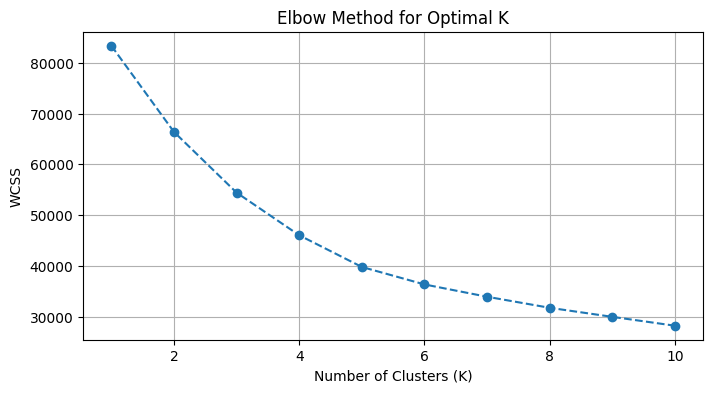

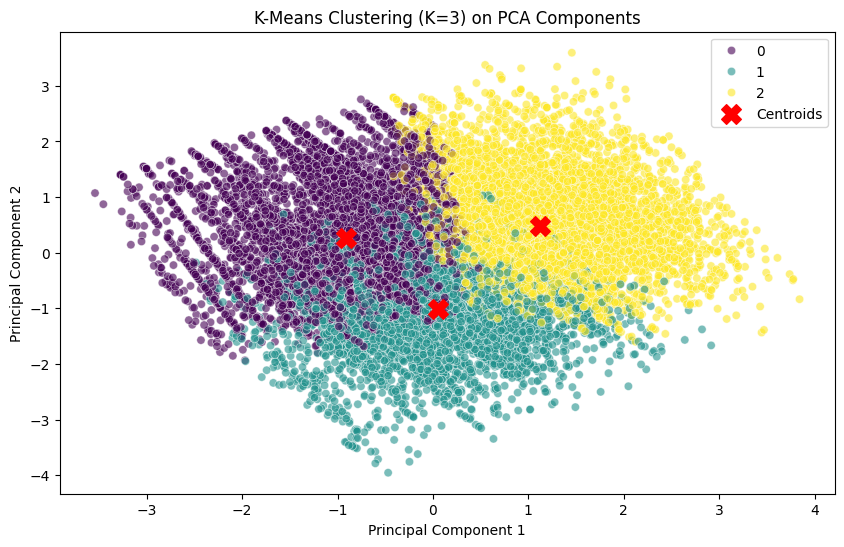

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
Cluster,,,,,,
0,27.977373,216574.712810,9.373056,277.858900,52.806800,34.916570
1,53.950691,165858.985626,9.007824,970.390466,87.477074,36.320779
2,39.531083,176326.786585,11.866746,2335.674747,131.142326,51.015021


In [64]:
from sklearn.cluster import KMeans

# 1. Prepare data for clustering (using PCA results from Step 5)
# X_train_pre already contains the PCA components
pca_features = [col for col in X_train_pre.columns if 'PCA' in col]
X_clustering = X_train_pre[pca_features]

# 2. Use Elbow Method to find optimal K
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_clustering)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(K_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# 3. Apply K-Means with an optimal K (let's assume K=3 based on typical Elbow behavior for this set)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_clustering)

# 4. Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_clustering.iloc[:, 0], y=X_clustering.iloc[:, 1], hue=clusters, palette='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title(f'K-Means Clustering (K={optimal_k}) on PCA Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

# 5. Add cluster labels back to the training dataframe for analysis
X_train_with_clusters = X_train.copy()
X_train_with_clusters['Cluster'] = clusters
display(X_train_with_clusters.groupby('Cluster').mean(numeric_only=True))

In [65]:
from sklearn.metrics import silhouette_score

# 1. Statistical Validation: Silhouette Score
# We take a sample if the dataset is large to speed up calculation
sample_size = 5000
if len(X_clustering) > sample_size:
    idx = np.random.choice(len(X_clustering), sample_size, replace=False)
    score = silhouette_score(X_clustering.iloc[idx], clusters[idx])
else:
    score = silhouette_score(X_clustering, clusters)

print(f'Silhouette Score for K=3: {score:.4f}')
print('Interpretation: Scores near 0 indicate overlapping clusters, while higher scores indicate better separation.')

Silhouette Score for K=3: 0.2244
Interpretation: Scores near 0 indicate overlapping clusters, while higher scores indicate better separation.


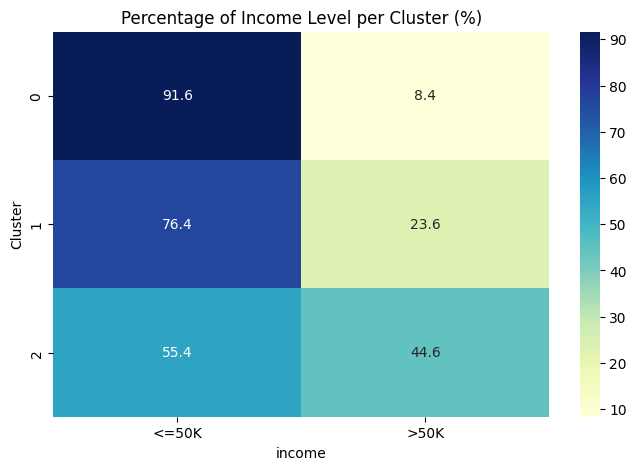

income,<=50K,>50K
Cluster,,
0,91.633790,8.366210
1,76.382824,23.617176
2,55.398572,44.601428


In [66]:
# 2. Business Validation: Mapping Clusters to Income
X_train_with_clusters['income'] = y_train.values
cluster_income = pd.crosstab(X_train_with_clusters['Cluster'], X_train_with_clusters['income'], normalize='index') * 100

plt.figure(figsize=(8, 5))
sns.heatmap(cluster_income, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Percentage of Income Level per Cluster (%)')
plt.show()

display(cluster_income)